# <center>**Figure 3 : Supplementary Sensory Bundle Innervation**</center>

In [ ]:
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("ticks")

In [2]:
linewidth      = 0.75
scatter_size   = 6
scatter_alpha  = 0.75
linewidth_hist = 0.5
alpha_hist     = 0.35
title_fontsize = 8.5
label_fontsize = 7
tick_fontsize  = 6
labelpad       = 10

# Labels
label_kwargs = dict(fontsize = 16, va = "top", ha = "left")

# Output Folder
FOLDER = "../Figures/Figure_03"
DATA   = "../Analysis_Outputs/Sensory_Innervation"

Single use custom order.

In [3]:
comps = ["AL_Ipsi", "LON_Ipsi", "TRdl_Ipsi", "TRdm_Ipsi", "TRint_Ipsi", "TRv_Ipsi",
         "TRv_Contra", "TRint_Contra", "TRdm_Contra", "TRdl_Contra", "LON_Contra", "AL_Contra",
         "_",
         "MXneu_Ipsi", "LBneu_Ipsi", "T1neu_Ipsi", "T2neu_Ipsi", "T3neu_Ipsi",
         "_",
         "MXneu_Contra", "LBneu_Contra", "T1neu_Contra", "T2neu_Contra", "T3neu_Contra", 
         ]

In [4]:
# Fill NaNs with 0 only on real compartment columns; keep "_" as NaN (blank gap)
non_spacer = [c for c in comps if c != "_"]

# Inputs
psd_matrix = pd.read_parquet(f"{DATA}/Sensory_Innervation_PSDs_level2.parquet")
psd_matrix.set_index("Lineage", inplace = True)
psd_matrix = psd_matrix.reindex(columns = comps)
psd_matrix[non_spacer] = psd_matrix[non_spacer].fillna(0)

# Outputs
tbar_matrix = pd.read_parquet(f"{DATA}/Sensory_Innervation_TBars_level2.parquet")
tbar_matrix.set_index("Lineage", inplace = True)
tbar_matrix = tbar_matrix.reindex(columns = comps)
tbar_matrix[non_spacer] = tbar_matrix[non_spacer].fillna(0)

In [5]:
vmin, vmax = 0, 1

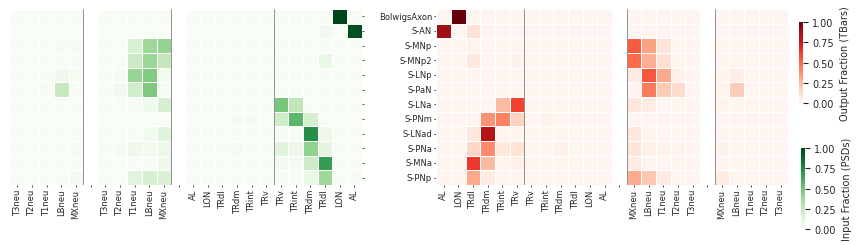

In [ ]:
fig, ax = plt.subplots(figsize = (11, 7), ncols = 2)
plt.subplots_adjust(wspace = 0)

# Heatmap
sns.heatmap(psd_matrix,
            cmap   = "Greens",
            square = True,
            ax     = ax[0],
            cbar_kws = {"shrink" : 0.15,
                        "anchor" : (7.15, 0.3),
                        "label"  : "Input Fraction (PSDs)",
                        "pad"    : 0.025},
            xticklabels = True,
            yticklabels = True,
            linewidths = 0.6,
            annot = False,
            vmin = vmin,
            vmax = vmax)

# Heatmap
sns.heatmap(tbar_matrix,
            cmap   = "Reds",
            square = True,
            ax     = ax[1],
            cbar_kws = {"shrink" : 0.15,
                        "anchor" : (0, 0.575),
                        "label"  : "Output Fraction (TBars)",
                        "pad"    : 0.025},
            xticklabels = True,
            yticklabels = True,
            linewidths = 0.6,
            annot = False,
            vmin = vmin,
            vmax = vmax)

# Labs
labs = ["Input Fraction (PSDs)", "Output Fraction (TBars)"]
# Loop
for i, a in enumerate(ax):
    # Grids
    a.grid(False)
    for s in a.spines.values():
        s.set_color("black")
        s.set_linewidth(0.6)
        s.set_visible(True)

    # C-BAR
    cbar = a.collections[0].colorbar
    cbar.set_label(labs[i], size = label_fontsize)
    cbar.ax.tick_params(labelsize = label_fontsize)
    # Update the ticks
    a.tick_params(
        axis      = "both",
        which     = "major",
        color     = "black",
        labelsize = tick_fontsize,
        length    = 1.5,
        width     = 0.5,
        pad       = 1.5)

    # Invert 
    a.invert_yaxis()

    # Remove the X-label
    a.set_xlabel("")
    a.set_ylabel("")

    # Update the bottom xticks to remove the Ipsi and Contra
    new_labels  = [label.get_text().split("_")[0] for label in a.get_xticklabels()]
    # Re-apply
    a.set_xticks(a.get_xticks())
    a.set_xticklabels(new_labels)

    # Line
    a.axvline(x = 6, color = "black", linewidth = 0.5, alpha = 0.6)
    a.axvline(x = 13, color = "black", linewidth = 0.5, alpha = 0.6)
    a.axvline(x = 19, color = "black", linewidth = 0.5, alpha = 0.6)

    # Despine
    sns.despine(ax = a, left = True, bottom = True)

# Invert 
ax[0].invert_xaxis()
ax[0].set_yticklabels([])
ax[0].yaxis.tick_right()

#--------------------------------------------------------
# Save the Figure
plt.savefig(f"{FOLDER}/Figure_03_Supplementary-06_Sensory-Bunble-Innervation.pdf",
            dpi = 1200,
            bbox_inches = "tight")

# <center>**हो गया दोस्तों!**</center>